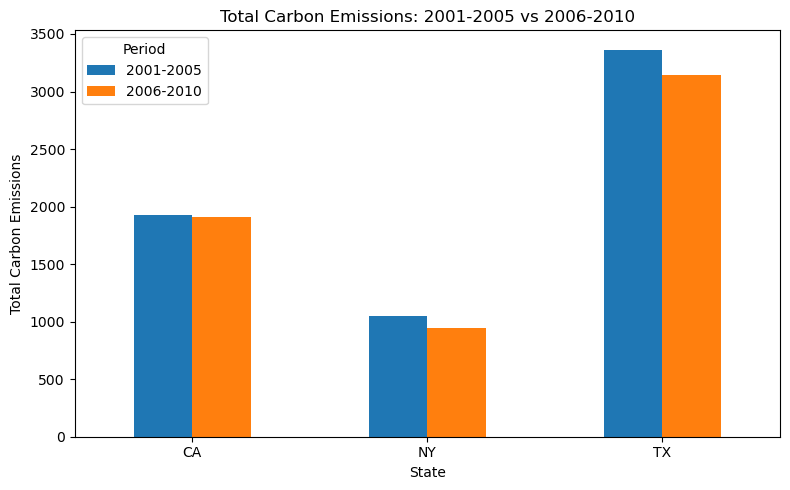

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as p9
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv("/Users/jasonbao/Downloads/state_total_co2_2001_2010.csv")

df["Period"] = df["Year"].apply(
    lambda y: "2001-2005" if 2001 <= y <= 2005 else "2006-2010"
)

period_summary = (
    df.groupby(["State", "Period"])["Total carbon emissions"]
    .sum()
    .unstack()
)

# Plot
period_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Total Carbon Emissions: 2001-2005 vs 2006-2010")
plt.xlabel("State")
plt.ylabel("Total Carbon Emissions")
plt.xticks(rotation=0)
plt.legend(title="Period")
plt.tight_layout()
plt.show()

From this bar plot, we can see that all three states have total carbon emission decrease. Specifically, Texas and New York decrease with a more obvious scale. For California, carbon emissions did change, but in a trivial scale. We interpret this difference as a variation of states' carbon-related energy reliability. For example, Texas is highly reliant on carbon energy. After imposing a policy, it would be easy to observe a shift of energy composition and thus a big difference. This change will study further in the following parts

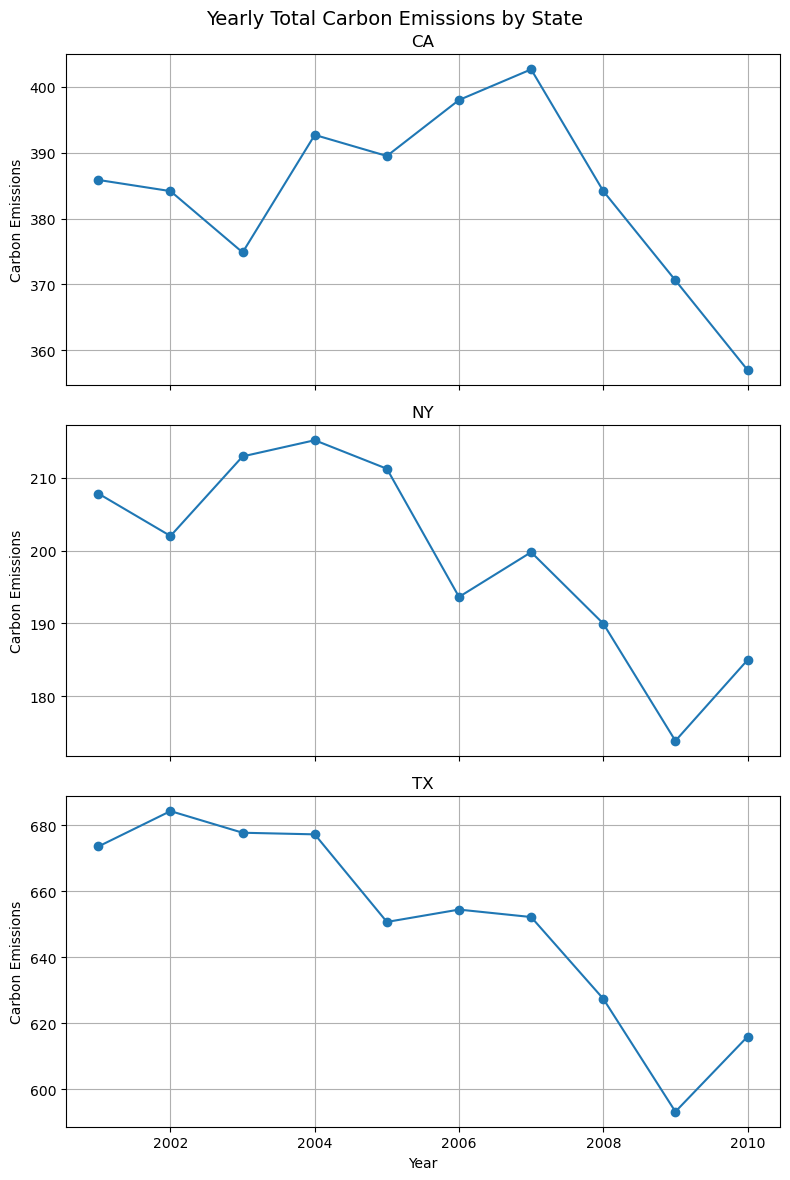

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

states = df["State"].unique()
for ax, state in zip(axes, states):
    state_data = df[df["State"] == state]
    
    ax.plot(
        state_data["Year"],
        state_data["Total carbon emissions"],
        marker="o"
    )
    
    ax.set_title(f"{state}")
    ax.set_ylabel("Carbon Emissions")
    ax.grid(True)

axes[-1].set_xlabel("Year")
plt.suptitle("Yearly Total Carbon Emissions by State", fontsize=14)
plt.tight_layout()
plt.show()

From each year's carbon emission line chart, we observe a significant drop in carbon emission in all states, indicating the energy policy kicks off rapidly.

### Next Step

Here we will dive in these three states further by looking at their energy usage decomposition. This section includes specific analysis on data patterns, and we will specify a state to analyze. From previous work, we see that texas has a large decrease in Carbon-based energy usage.

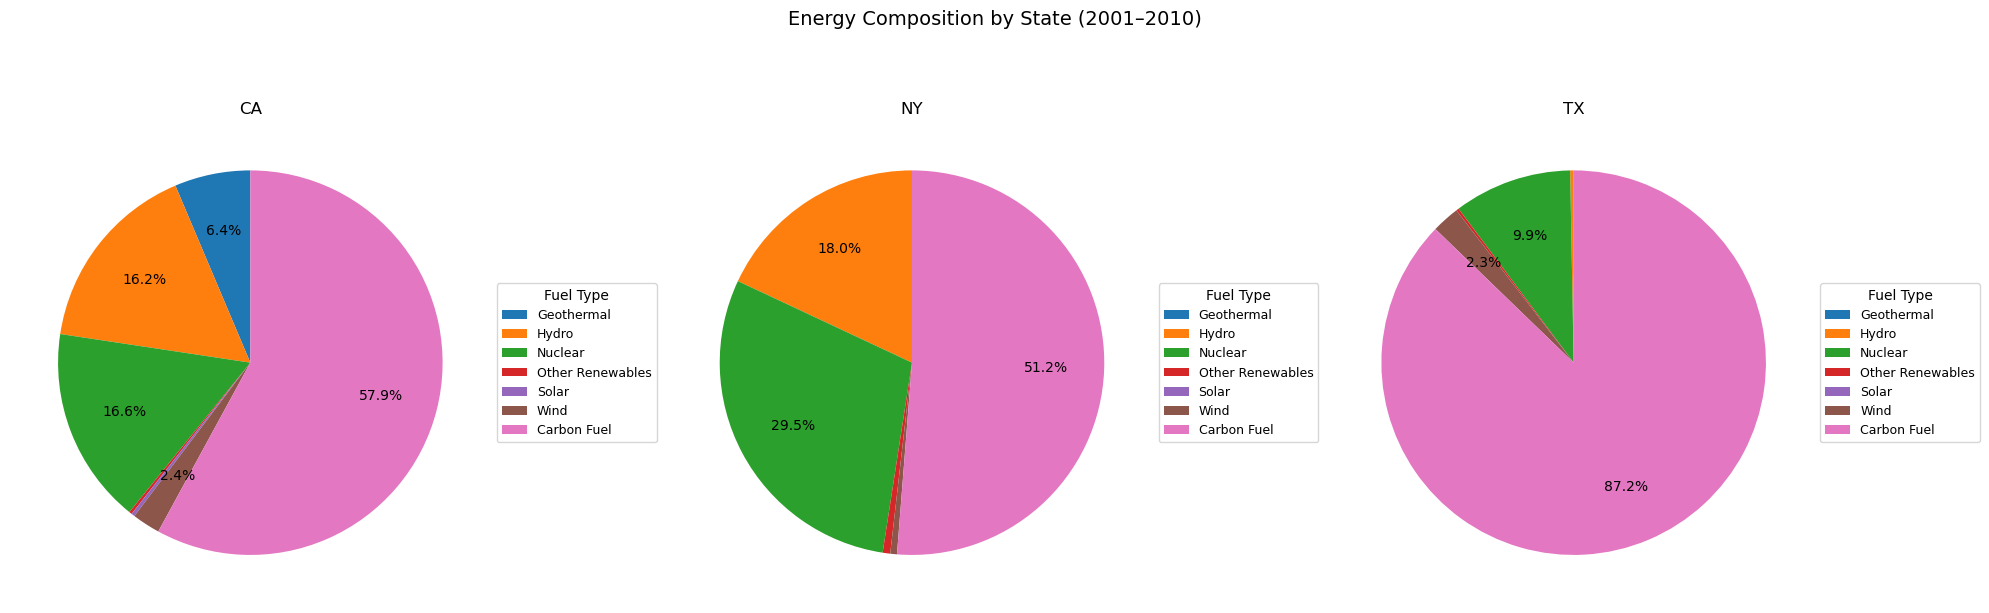

In [41]:

df = pd.read_csv("/Users/jasonbao/Downloads/all_fuels_clean1.csv")
import matplotlib.pyplot as plt

fuel_cols = [
    "Geothermal",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind",
    "carbon_related_fuel"
]

short_labels = [
    "Geothermal",
    "Hydro",
    "Nuclear",
    "Other Renewables",
    "Solar",
    "Wind",
    "Carbon Fuel"
]

states = df["State"].unique()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

def pct_fmt(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

for ax, state in zip(axes, states):
    state_data = df[df["State"] == state]
    fuel_totals = state_data[fuel_cols].sum()

    wedges, texts, autotexts = ax.pie(
        fuel_totals,
        labels=None,                 # remove direct labels
        autopct=pct_fmt,            # only show pct if >= 2%
        startangle=90,
        pctdistance=0.7
    )

    ax.set_title(f"{state}")

    # Put labels in a legend instead
    ax.legend(
        wedges,
        short_labels,
        title="Fuel Type",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=9
    )

plt.suptitle("Energy Composition by State (2001–2010)", fontsize=14)
plt.tight_layout()
plt.show()

Specifically, Texas' carbon fuel is a high-weight sector, taking 87.2% of their total energy. Whereas from our hypothesis, non-carbon-base energy section will expand because of the energy policy. We will analyze this using different graphs by matplotlib, seaborn or plotnine

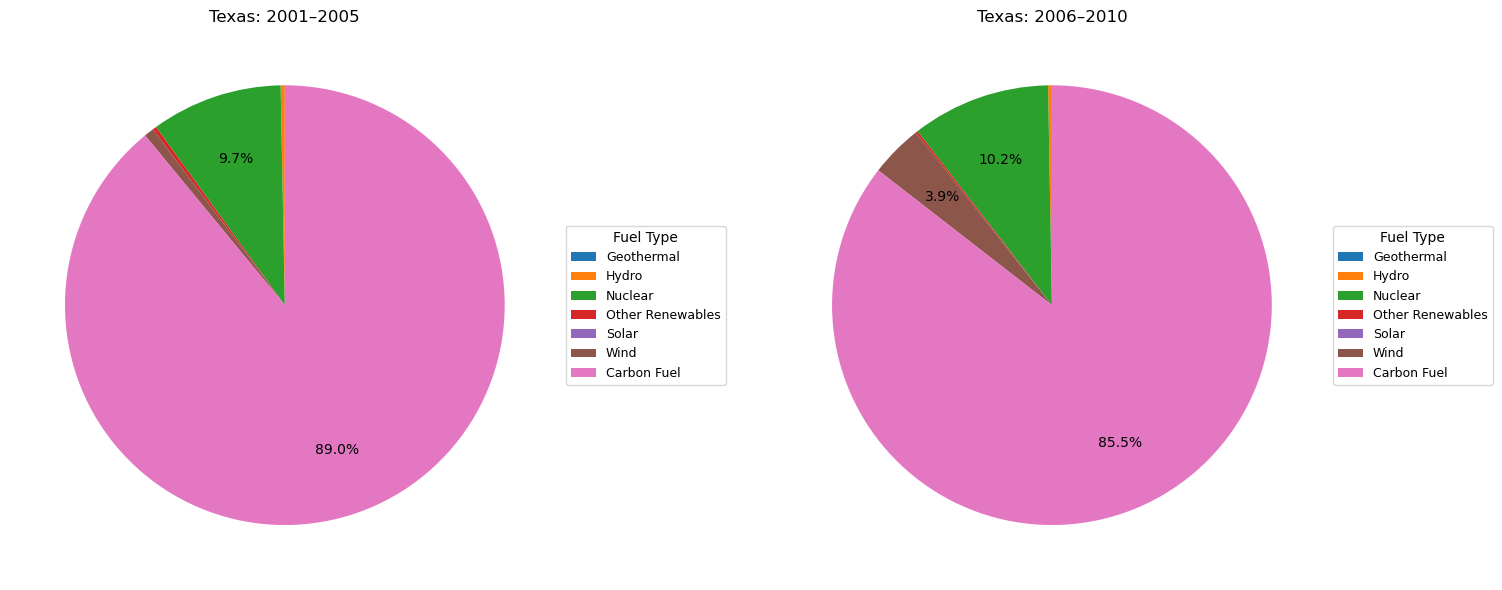

In [43]:
import matplotlib.pyplot as plt

tx = df[df["State"] == "TX"].copy()

fuel_cols = [
    "Geothermal",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind",
    "carbon_related_fuel"
]

labels = [
    "Geothermal",
    "Hydro",
    "Nuclear",
    "Other Renewables",
    "Solar",
    "Wind",
    "Carbon Fuel"
]

tx_2001_2005 = tx[(tx["Year"] >= 2001) & (tx["Year"] <= 2005)][fuel_cols].sum()
tx_2006_2010 = tx[(tx["Year"] >= 2006) & (tx["Year"] <= 2010)][fuel_cols].sum()

def pct_fmt(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wedges0, texts0, autotexts0 = axes[0].pie(
    tx_2001_2005,
    labels=None,
    autopct=pct_fmt,
    startangle=90,
    pctdistance=0.7
)
axes[0].set_title("Texas: 2001–2005")
axes[0].legend(
    wedges0,
    labels,
    title="Fuel Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

wedges1, texts1, autotexts1 = axes[1].pie(
    tx_2006_2010,
    labels=None,
    autopct=pct_fmt,
    startangle=90,
    pctdistance=0.7
)
axes[1].set_title("Texas: 2006–2010")
axes[1].legend(
    wedges1,
    labels,
    title="Fuel Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

plt.tight_layout()
plt.show()

By some easy calculations, we can see that renewable energy increase by 3.5%. This, compared with the original 11% base, is a 32% percentage increase for non-carbon fuel sector. Therefore, this is a strong evidence to prove that the energy policy functioned well in 2005.

The 7-variable OLS regression for Texas suggests that the energy variables collectively explain a large portion of the variation in total carbon emissions (R^2= 0.929), but the overall model is only marginally significant (p=0.0758). Among the predictors, wind energy shows the strongest relationship with emissions, with a negative coefficient and borderline significance (p=0.052), suggesting that greater wind usage may be associated with lower carbon emissions. However, none of the predictors are statistically significant at the 5% level. Because the model uses many predictors with only 10 yearly observations, and because the output indicates severe multicollinearity, the individual coefficient estimates should be interpreted cautiously.

The reduced 4-variable OLS model provides a better fit than the full 7-variable model. It explains a large proportion of the variation in Texas total carbon emissions (R^2 =0.924, adjusted R^2 =0.864) and is statistically significant overall (F-test p = 0.00523). Among the predictors, wind energy has a statistically significant negative coefficient (p = 0.003), suggesting that greater wind usage is associated with lower carbon emissions in Texas, holding the other included variables fixed. Solar energy has a positive coefficient and is marginally significant at the 10% level (p = 0.063), while carbon-related fuel and other renewables are not statistically significant in this model. Although the reduced model is more stable and interpretable, the small sample size and remaining multicollinearity suggest that results should still be interpreted with caution.

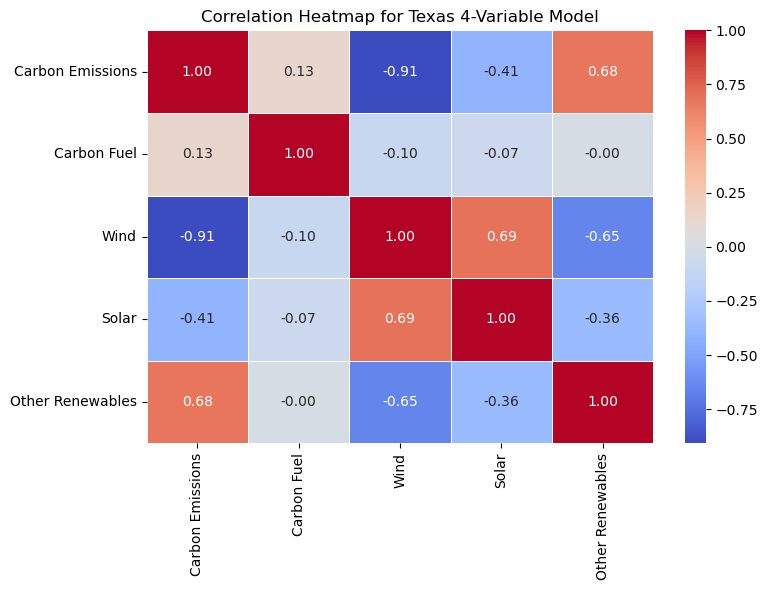

In [23]:

tx = pd.merge(tx_emissions, tx_fuels, on=["State", "Year"], how="inner")

plot_df = tx[
    [
        "Total carbon emissions",
        "carbon_related_fuel",
        "Wind",
        "Solar Thermal and Photovoltaic",
        "Other_Renewables"
    ]
].copy()

# Shorter labels for cleaner plot
plot_df.columns = [
    "Carbon Emissions",
    "Carbon Fuel",
    "Wind",
    "Solar",
    "Other Renewables"
]

# Correlation matrix
corr = plot_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap for Texas 4-Variable Model")
plt.tight_layout()
plt.show()

The heatmap shows that wind has the strongest relationship with Texas total carbon emissions, with a very strong negative correlation of -0.91. This supports the regression result, where wind was also the most statistically important predictor and had a negative coefficient. Other renewables show a moderately positive correlation with emissions (0.68), while solar has a moderate negative correlation (-0.41). However, wind and solar are themselves positively correlated (0.69), and wind is negatively correlated with other renewables (-0.65), indicating that some multicollinearity remains even in the reduced model. Carbon-related fuel has only a weak correlation with emissions (0.13), which is consistent with its lack of significance in the regression.

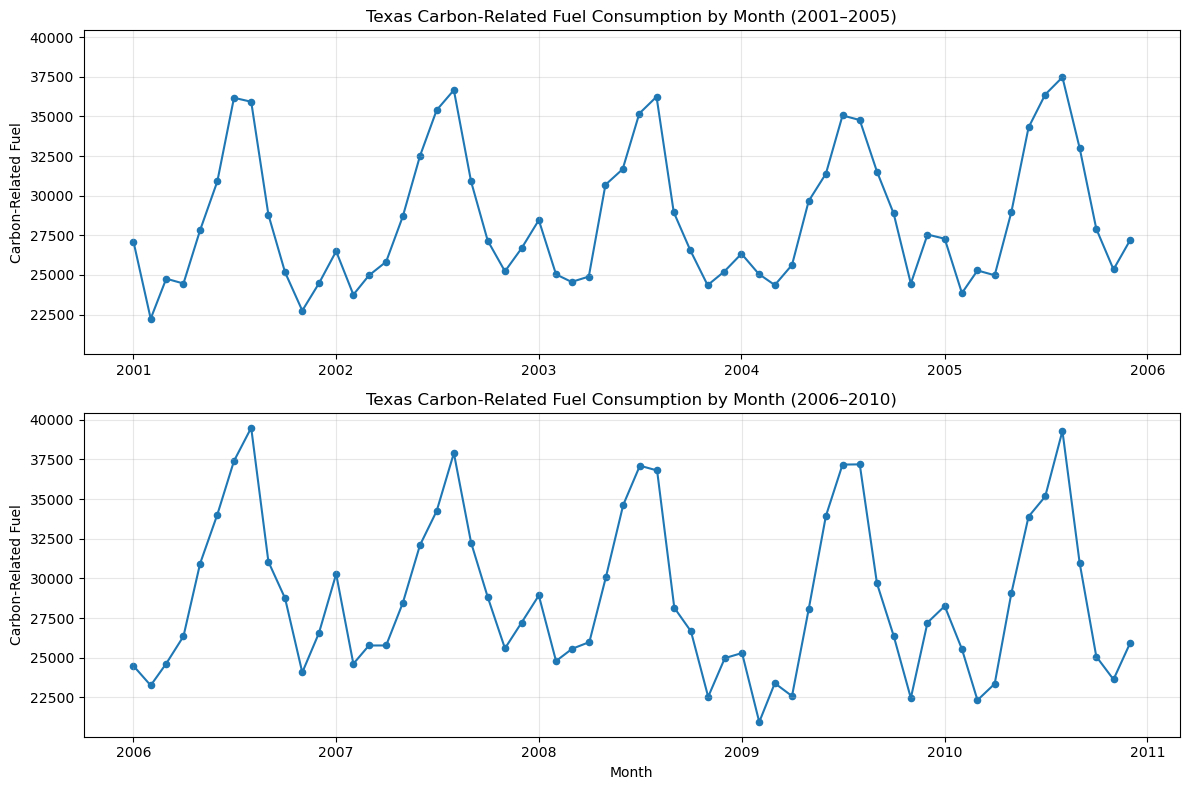

In [24]:
df = pd.read_csv("TX_fuels_clean1.csv")

# Keep only Texas and needed columns
df = df[df["STATE"] == "TX"][["YEAR", "MONTH", "carbon_related_fuel"]].copy()

# Convert to integers
df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

# Create date column
df["Date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))

# Split periods
df1 = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2005)].sort_values("Date")
df2 = df[(df["YEAR"] >= 2006) & (df["YEAR"] <= 2010)].sort_values("Date")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)

axes[0].plot(df1["Date"], df1["carbon_related_fuel"])
axes[0].scatter(df1["Date"], df1["carbon_related_fuel"],s=20)
axes[0].set_title("Texas Carbon-Related Fuel Consumption by Month (2001–2005)")
axes[0].set_ylabel("Carbon-Related Fuel")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df2["Date"], df2["carbon_related_fuel"])
axes[1].scatter(df2["Date"], df2["carbon_related_fuel"],s=20)
axes[1].set_title("Texas Carbon-Related Fuel Consumption by Month (2006–2010)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Carbon-Related Fuel")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This is a monthly time series because the data are ordered over time, and the plot shows a clear seasonal pattern rather than random variation. In both 2001–2005 and 2006–2010, carbon-related fuel consumption rises and falls in a similar yearly cycle, with repeated peaks and dips, while the overall level stays fairly stable without a strong long-term upward or downward trend. The later period seems slightly more variable, but the main feature of the graph is its regular seasonal behavior. 

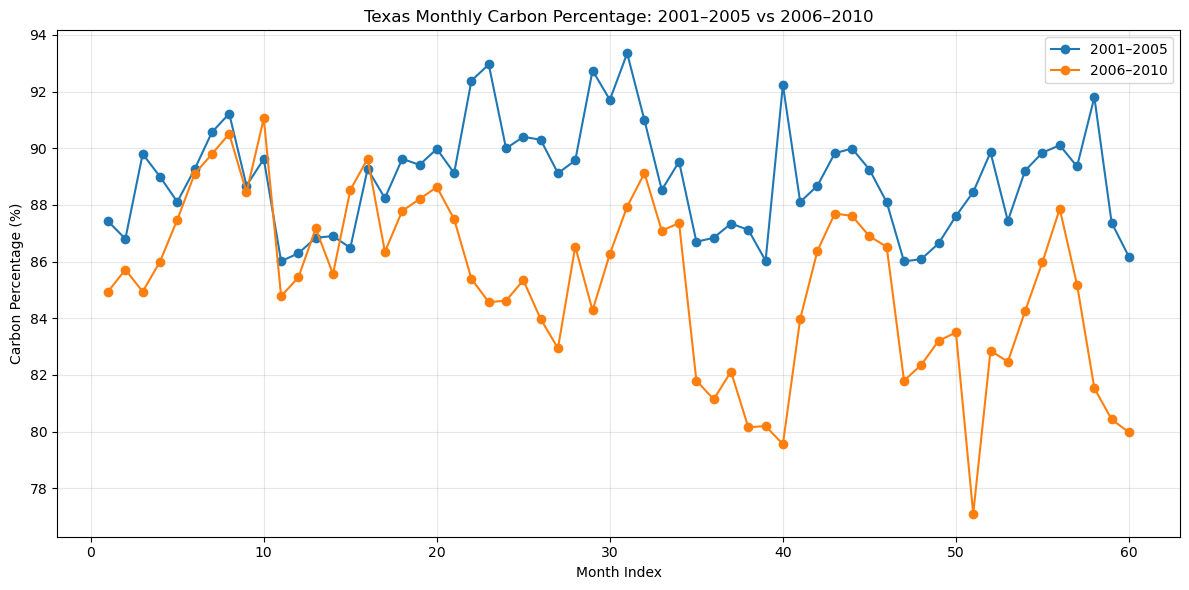

In [25]:


df = pd.read_csv("TX_fuels_clean1.csv")
# Convert types
df = df[df["STATE"] == "TX"].copy()

# Convert types
df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

df["YEAR"] = df["YEAR"].astype(int)
df["MONTH"] = df["MONTH"].astype(int)

df["carbon%"] = (df["carbon_related_fuel"] / df["Total"]) * 100

# Create date column
df["Date"] = pd.to_datetime(dict(year=df["YEAR"], month=df["MONTH"], day=1))
# Split periods
df1 = df[(df["YEAR"] >= 2001) & (df["YEAR"] <= 2005)].sort_values("Date")
df2 = df[(df["YEAR"] >= 2006) & (df["YEAR"] <= 2010)].sort_values("Date")

# Use month index within each period so the two periods align on one graph
df1["Month_Index"] = range(1, len(df1) + 1)
df2["Month_Index"] = range(1, len(df2) + 1)

# Plot both on one graph
plt.figure(figsize=(12, 6))

plt.plot(df1["Month_Index"], df1["carbon%"], marker="o", label="2001–2005")
plt.plot(df2["Month_Index"], df2["carbon%"], marker="o", label="2006–2010")

plt.xlabel("Month Index")
plt.ylabel("Carbon Percentage (%)")
plt.title("Texas Monthly Carbon Percentage: 2001–2005 vs 2006–2010")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

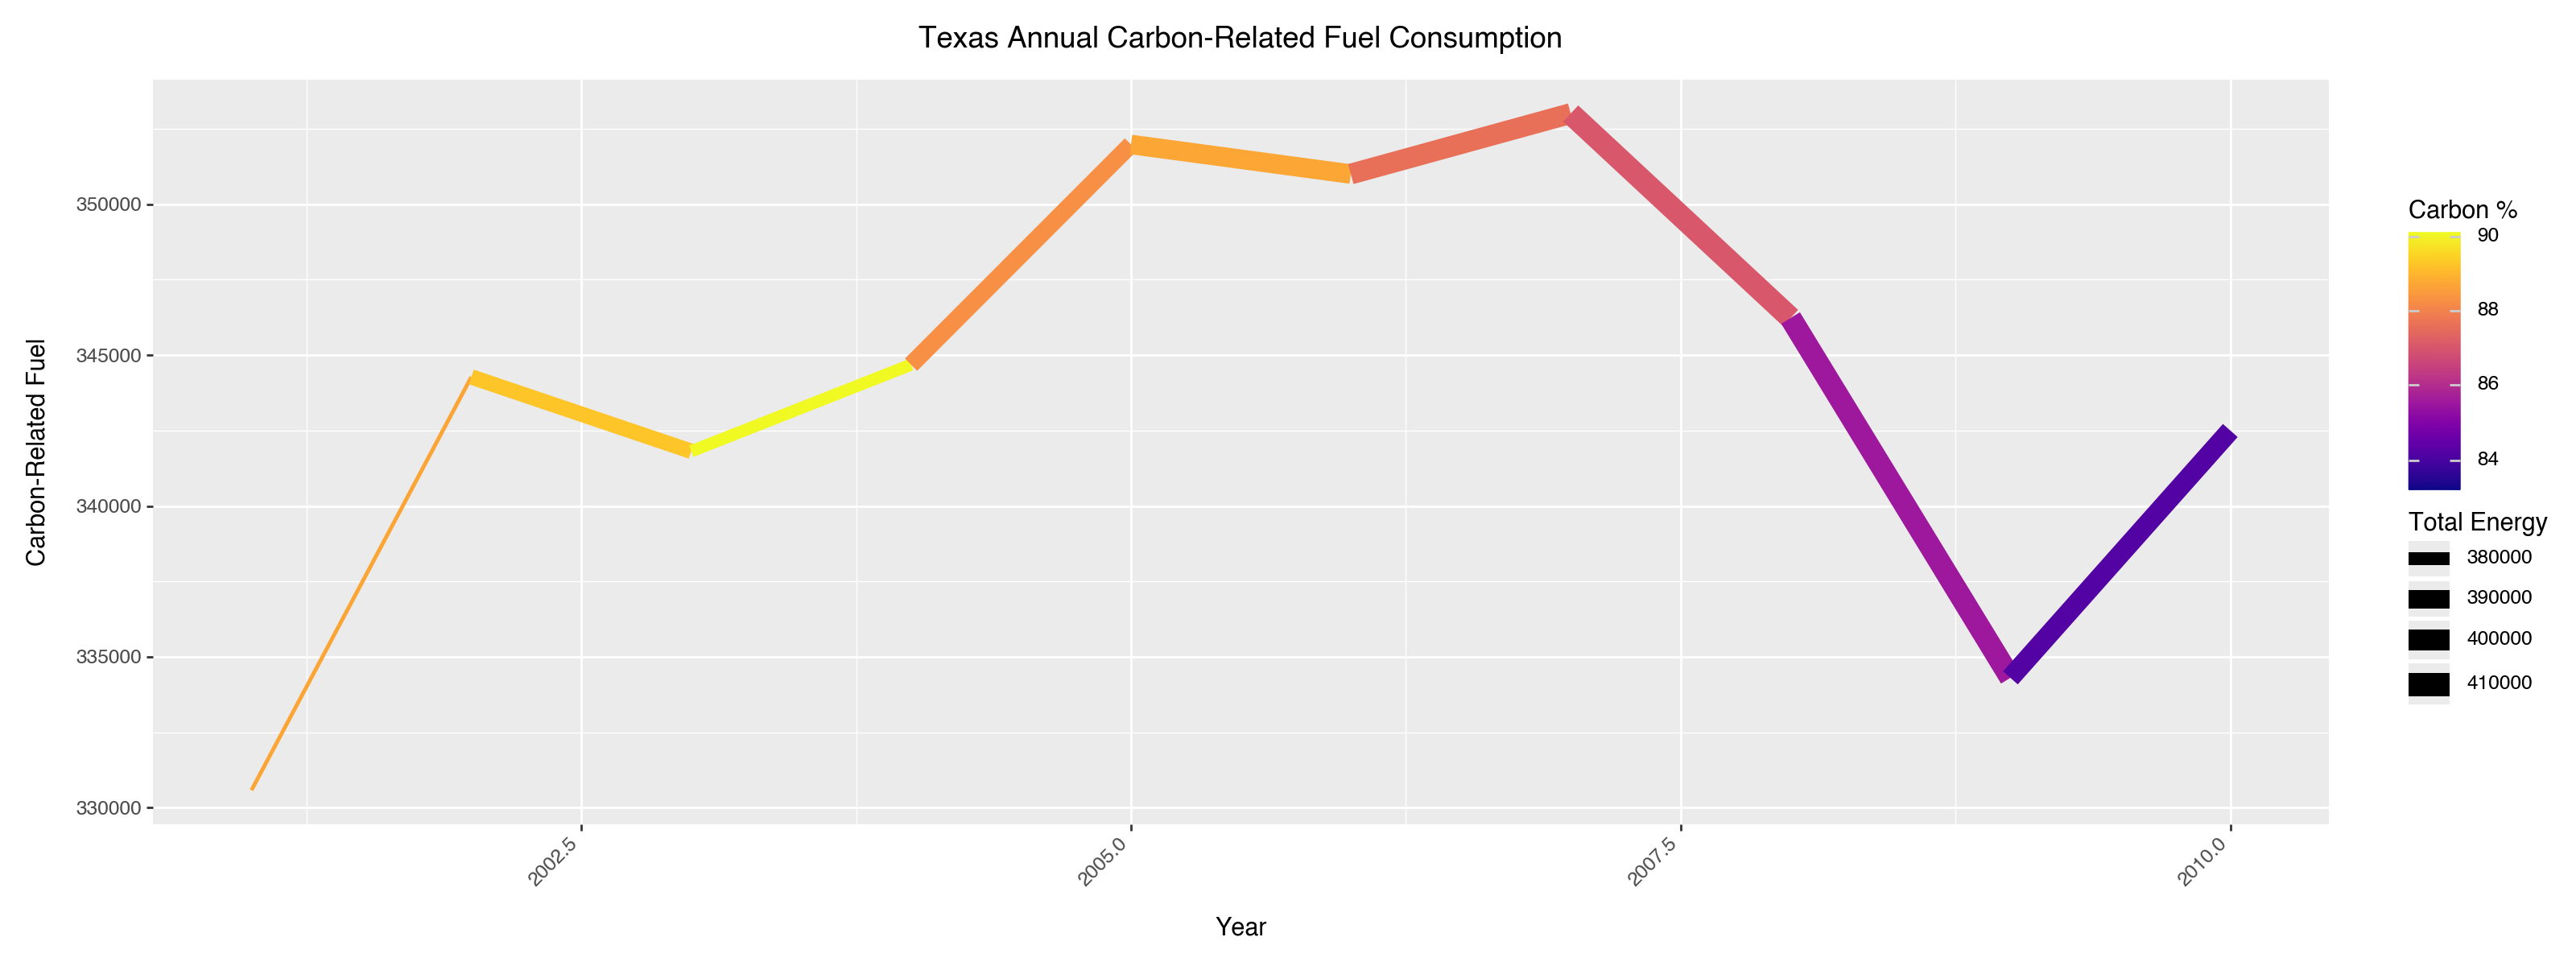

In [27]:
# Load annual data
df = pd.read_csv("all_fuels_clean1.csv")

# Keep only Texas
df = df[df["State"] == "TX"].copy()

# Convert year
df["Year"] = df["Year"].astype(int)

# Add carbon percentage
df["carbon_pct"] = 100 * df["carbon_related_fuel"] / df["Total"]

# Sort by year
df = df.sort_values("Year")

p = (
    p9.ggplot(
        df,
        p9.aes(
            x="Year",
            y="carbon_related_fuel",
            color="carbon_pct",
            size="Total",
            group=1
        )
    )
    + p9.geom_path()
    + p9.labs(
        title="Texas Annual Carbon-Related Fuel Consumption",
        x="Year",
        y="Carbon-Related Fuel",
        color="Carbon %",
        size="Total Energy"
    )
    + p9.scale_color_cmap(
        name="Carbon %",
        cmap_name="plasma"
    )
    + p9.theme_gray()
    + p9.theme(
        figure_size=(16, 6),
        axis_text_x=p9.element_text(rotation=45, ha="right")
    )
)

p

Now with monthly energy consumption, we aim to construct a model to approximate the change of carbon percentage with respect to different portions of energy (either carbon-related or not). 

In [29]:
import pandas as pd
import numpy as np

tx_monthly = pd.read_csv("/Users/jasonbao/Downloads/TX_fuels_clean1.csv")
tx_monthly = tx_monthly[tx_monthly["STATE"] == "TX"].copy()

tx_monthly["YEAR"] = tx_monthly["YEAR"].astype(int)
tx_monthly["MONTH"] = tx_monthly["MONTH"].astype(int)
tx_monthly["Date"] = pd.to_datetime(dict(year=tx_monthly["YEAR"], month=tx_monthly["MONTH"], day=1))

tx_monthly["carbon_pct"] = 100 * tx_monthly["carbon_related_fuel"] / tx_monthly["Total"]

tx_monthly = tx_monthly.sort_values("Date").reset_index(drop=True)

tx_monthly.head()

,STATE,YEAR,MONTH,Hydroelectric Conventional,Nuclear,Other_Renewables,Solar Thermal and Photovoltaic,Total,Wind,carbon_related_fuel,Date,carbon_pct
0,TX,2001,1,138.093,3545.310,132.652,0.0,31001.280,83.931,27101.293,2001-01-01,87.419916
1,TX,2001,2,110.148,3037.626,92.545,0.0,25626.521,141.647,22244.555,2001-02-01,86.802867
2,TX,2001,3,180.140,2462.837,82.436,0.0,27580.339,87.631,24767.295,2001-03-01,89.800546
3,TX,2001,4,124.232,2668.816,116.114,0.0,27486.315,115.487,24461.666,2001-04-01,88.995800
4,TX,2001,5,115.102,3419.870,117.563,0.0,31583.459,103.312,27827.612,2001-05-01,88.108183


Checking back of  monthy carbon-related fuel percentageThe monthly carbon percentage series appears to move over time with visible seasonal fluctuation, and this suggests that a regression model should account for both the energy mix and time structure.

In [31]:
predictors = [
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind"
]

model_df = tx_monthly[["Date", "YEAR", "MONTH", "carbon_pct"] + predictors].copy()
model_df.head()

,Date,YEAR,MONTH,carbon_pct,Hydroelectric Conventional,Nuclear,Other_Renewables,Solar Thermal and Photovoltaic,Wind
0,2001-01-01,2001,1,87.419916,138.093,3545.310,132.652,0.0,83.931
1,2001-02-01,2001,2,86.802867,110.148,3037.626,92.545,0.0,141.647
2,2001-03-01,2001,3,89.800546,180.140,2462.837,82.436,0.0,87.631
3,2001-04-01,2001,4,88.995800,124.232,2668.816,116.114,0.0,115.487
4,2001-05-01,2001,5,88.108183,115.102,3419.870,117.563,0.0,103.312


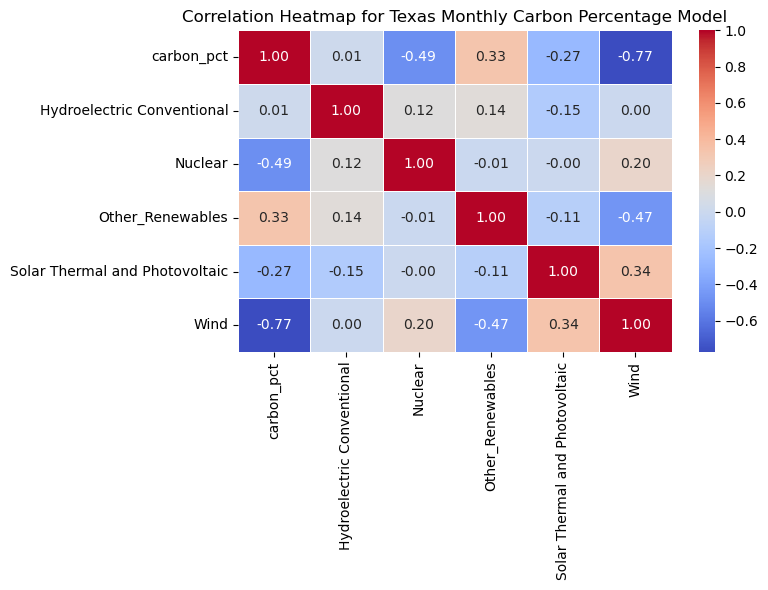

In [48]:

corr_df = model_df[["carbon_pct"] + predictors].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap for Texas Monthly Carbon Percentage Model")
plt.tight_layout()
plt.show()

This heatmap shows how carbon_pct is linearly related to each energy source and also how the predictors relate to one another. The strongest pattern is that wind has a strong negative correlation with carbon percentage at about -0.77, suggesting that months with higher wind generation tend to have lower carbon dependence. Nuclear also has a moderate negative correlation with carbon_pct around -0.49, while other renewables has a modest positive correlation around 0.33. Hydroelectric conventional is almost uncorrelated with carbon_pct, so by itself it does not show a clear linear relationship. Among the predictors, most pairwise correlations are only small to moderate, which is helpful because it suggests multicollinearity is not extreme, although wind and other renewables do show some negative association. Overall, the heatmap suggests that wind is the most important candidate for explaining lower Texas carbon percentage, while hydro appears much less informative in a simple correlation view.

In [99]:
predictors = [
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Solar Thermal and Photovoltaic",
    "Wind"
]

model_df = tx_monthly[["Date", "YEAR", "carbon_pct"] + predictors].copy()
model_df.head()

,Date,YEAR,carbon_pct,Hydroelectric Conventional,Nuclear,Other_Renewables,Solar Thermal and Photovoltaic,Wind
0,2001-01-01,2001,87.419916,138.093,3545.310,132.652,0.0,83.931
1,2001-02-01,2001,86.802867,110.148,3037.626,92.545,0.0,141.647
2,2001-03-01,2001,89.800546,180.140,2462.837,82.436,0.0,87.631
3,2001-04-01,2001,88.995800,124.232,2668.816,116.114,0.0,115.487
4,2001-05-01,2001,88.108183,115.102,3419.870,117.563,0.0,103.312


In [100]:
train_df = model_df[model_df["YEAR"] <= 2009].copy()
test_df = model_df[model_df["YEAR"] > 2009].copy()

X_train = train_df.drop(columns=["Date", "carbon_pct"])
y_train = train_df["carbon_pct"]

X_test = test_df.drop(columns=["Date", "carbon_pct"])
y_test = test_df["carbon_pct"]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (108, 6) (108,)
Test shape: (12, 6) (12,)


In [101]:

X_train_ols = sm.add_constant(X_train).astype(float)
X_test_ols = sm.add_constant(X_test, has_constant="add").astype(float)

y_train_ols = y_train.astype(float)
y_test_ols = y_test.astype(float)

ols_model = sm.OLS(y_train_ols, X_train_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             carbon_pct   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     49.22
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.11e-25
Time:                        19:53:07   Log-Likelihood:                -197.30
No. Observations:                 108   AIC:                             406.6
Df Residuals:                     102   BIC:                             422.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide


Here we see that this model has an unstable adjusted R^2. Also, because the main question is whether the 2005 renewable-energy policy changed Texas’s carbon dependence, the analysis should focus on policy impact rather than pure prediction accuracy. Therefore, we use an interrupted time series framework with a post-policy indicator and a post-policy trend interaction. This allows us to test both an immediate change in carbon percentage and a change in its long-run trend after the policy.

In [126]:
model_df = tx_monthly[[
    "Date", "YEAR", "carbon_pct",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Wind"
]].copy()

model_df = model_df.sort_values("Date").reset_index(drop=True)

# monthly time index
model_df["time"] = range(1, len(model_df) + 1)

# policy indicator: 1 for 2005 and after
model_df["post_policy"] = (model_df["YEAR"] >= 2005).astype(int)

# interaction: trend change after policy
model_df["time_post"] = model_df["time"] * model_df["post_policy"]

model_df.head()

,Date,YEAR,carbon_pct,Hydroelectric Conventional,Nuclear,Other_Renewables,Wind,time,post_policy,time_post
0,2001-01-01,2001,87.419916,138.093,3545.310,132.652,83.931,1,0,0
1,2001-02-01,2001,86.802867,110.148,3037.626,92.545,141.647,2,0,0
2,2001-03-01,2001,89.800546,180.140,2462.837,82.436,87.631,3,0,0
3,2001-04-01,2001,88.995800,124.232,2668.816,116.114,115.487,4,0,0
4,2001-05-01,2001,88.108183,115.102,3419.870,117.563,103.312,5,0,0


In [127]:

X = model_df[["time", "post_policy", "time_post"]]
X = sm.add_constant(X).astype(float)
y = model_df["carbon_pct"].astype(float)

policy_model = sm.OLS(y, X).fit()
print(policy_model.summary())

                            OLS Regression Results                            
Dep. Variable:             carbon_pct   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     36.66
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           9.69e-17
Time:                        20:02:35   Log-Likelihood:                -266.62
No. Observations:                 120   AIC:                             541.2
Df Residuals:                     116   BIC:                             552.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          89.0288      0.666    133.735      

In [128]:
X_ctrl = model_df[[
    "time", "post_policy", "time_post",
    "Hydroelectric Conventional",
    "Nuclear",
    "Other_Renewables",
    "Wind"
]]
X_ctrl = sm.add_constant(X_ctrl).astype(float)
y = model_df["carbon_pct"].astype(float)

policy_model_ctrl = sm.OLS(y, X_ctrl).fit()
print(policy_model_ctrl.summary())

                            OLS Regression Results                            
Dep. Variable:             carbon_pct   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     50.85
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           6.53e-32
Time:                        20:02:50   Log-Likelihood:                -220.84
No. Observations:                 120   AIC:                             457.7
Df Residuals:                     112   BIC:                             480.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

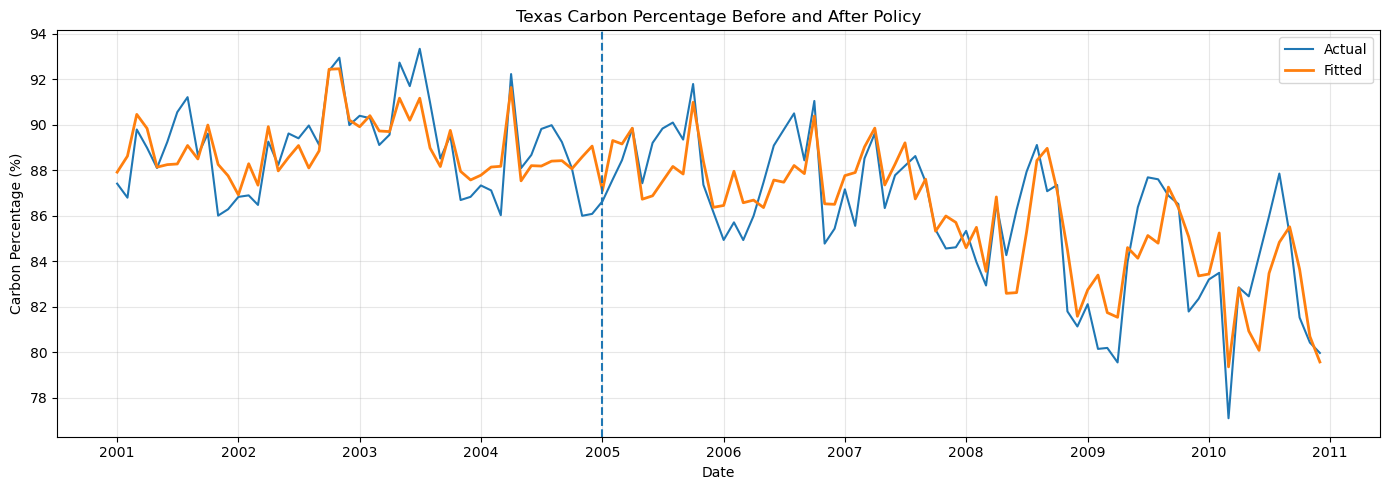

In [130]:

model_df["fitted_policy"] = policy_model_ctrl.predict(X_ctrl)

plt.figure(figsize=(14, 5))
plt.plot(model_df["Date"], model_df["carbon_pct"], label="Actual")
plt.plot(model_df["Date"], model_df["fitted_policy"], label="Fitted", linewidth=2)
plt.axvline(pd.Timestamp("2005-01-01"), linestyle="--")
plt.title("Texas Carbon Percentage Before and After Policy")
plt.xlabel("Date")
plt.ylabel("Carbon Percentage (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This fitted-line plot suggests that the interrupted time series model captures the main movement in Texas carbon percentage fairly well. The fitted values track the actual series closely across most of the 2001–2010 period, which means the model is picking up the overall pattern rather than missing it entirely. Before the 2005 policy line, carbon percentage stays relatively high and fairly stable, mostly in the upper-80% range. After 2005, the series still fluctuates month to month, but there is a clearer downward movement over time, with carbon percentage gradually falling into the mid-80% and sometimes lower by the end of the sample. This pattern is consistent with the idea that the renewable-energy policy may have contributed to a reduction in Texas’s carbon dependence, not necessarily through an immediate sharp drop, but through a longer-run decline in the carbon share of total energy consumption.

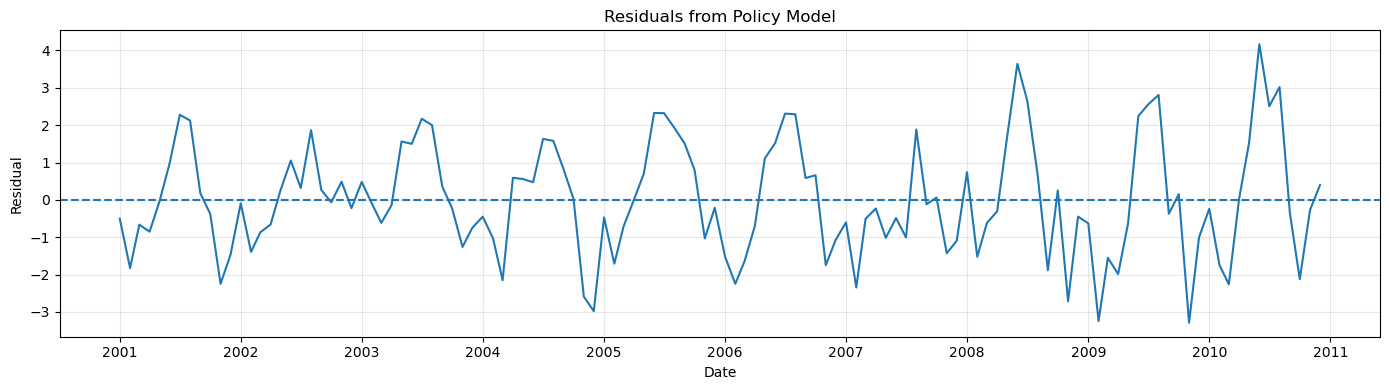

In [131]:
model_df["residuals"] = model_df["carbon_pct"] - model_df["fitted_policy"]

plt.figure(figsize=(14, 4))
plt.plot(model_df["Date"], model_df["residuals"])
plt.axhline(0, linestyle="--")
plt.title("Residuals from Policy Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Finally, we end this model study by a residual plot. This residual plot suggests that the policy model captures the overall trend in Texas carbon percentage, since the residuals fluctuate around zero rather than staying mostly positive or mostly negative. That means the fitted values are not systematically too high or too low across the whole period. At the same time, the residuals still show some short runs and repeating swings, rather than looking like completely random noise, which suggests there is still remaining time structure such as seasonality or autocorrelation that the model has not fully explained. The larger spikes in the later years also indicate that the model misses some sharper month-to-month changes after the policy period. So overall, the model does a reasonable job fitting the broad pattern, but the residual plot shows that it does not capture all of the detailed monthly variation.